In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [49]:
def deconvolve_spectrum_fiddle(reference_peak, spectrum, peak_location, margin=96, full_output=False):

    # get reference spectrum by placing reference peak at the same location as the peak in the spectrum
    reference_spectrum = np.zeros_like(spectrum)
    left_bound = peak_location - np.argmax(reference_peak)
    reference_spectrum[left_bound:left_bound+len(reference_peak)] = reference_peak

    # zero noised spectrum outside peak region
    noised_peak = np.zeros_like(spectrum)
    noised_peak[peak_location-margin:peak_location+margin+1] = spectrum[peak_location-margin:peak_location+margin+1]

    # calculate FIDs
    reference_fid = np.fft.ifft(reference_spectrum)
    noised_peak_fid = np.fft.ifft(noised_peak)
    noised_full_fid = np.fft.ifft(spectrum)

    # deconvolve FIDs
    correction_function = reference_fid / noised_peak_fid
    corrected_fid = noised_full_fid * correction_function

    # get corrected spectrum
    corrected_spectrum_complex = np.fft.fft(corrected_fid)
    energy_lost = np.sum(np.abs(corrected_spectrum_complex)) / np.sum(np.abs(spectrum))
    corrected_spectrum = np.real(corrected_spectrum_complex)

    if full_output:
        return {
            'reference_spectrum': reference_spectrum,
            'noised_peak': noised_peak,
            'reference_fid': reference_fid,
            'noised_peak_fid': noised_peak_fid,
            'noised_full_fid': noised_full_fid,
            'correction_function': correction_function,
            'corrected_fid': corrected_fid,
            'corrected_spectrum': corrected_spectrum,
            'corrected_spectrum_complex': corrected_spectrum_complex,
            'energy_lost': energy_lost
        }
    else:
        return corrected_spectrum



# Mono-click

In [40]:
reference_spectrum1_chemical_shift, reference_spectrum1 = np.loadtxt("../../dane/reaction_monitoring/mono-click/mono-click_przed_reakcja.csv").T
reference_spectrum2_chemical_shift, reference_spectrum2 = np.loadtxt("../../dane/reaction_monitoring/mono-click/mono-click_po_reakcji.csv").T

reference_spectrum1 /= np.max(reference_spectrum1)
reference_spectrum2 /= np.max(reference_spectrum2)

In [41]:
reaction_data = np.loadtxt("../../dane/reaction_monitoring/mono-click/20Aug2025_seria_87-4ppm.csv", skiprows=1, max_rows=17364)
reaction_spectra = reaction_data[:, 1:].T
reaction_spectra /= np.max(reaction_spectra, axis=1, keepdims=True)
reaction_chemical_shifts = reaction_data[:, 0]

In [42]:
peak1_reference_position_ppm = 4.427989
peak1_reaction_position_ppm = 4.383201

peak2_reference_position_ppm = 5.623770
peak2_reaction_position_ppm = 5.598032

def get_peak_location(chemical_shifts, spectrum, target_ppm, margin=10):
    points_per_ppm = (len(chemical_shifts)-1) / (chemical_shifts[-1] - chemical_shifts[0])
    approx_from_ppm = round((target_ppm - chemical_shifts[0]) * points_per_ppm)
    return approx_from_ppm + np.argmax(spectrum[approx_from_ppm-margin:approx_from_ppm+margin+1]) - margin

peak1_reference_position_index = get_peak_location(reference_spectrum1_chemical_shift, reference_spectrum1, peak1_reference_position_ppm)
peak1_reaction_position_index = get_peak_location(reaction_chemical_shifts, reaction_spectra[0], peak1_reaction_position_ppm)

peak2_reference_position_index = get_peak_location(reference_spectrum2_chemical_shift, reference_spectrum2, peak2_reference_position_ppm)
peak2_reaction_position_index = get_peak_location(reaction_chemical_shifts, reaction_spectra[-1], peak2_reaction_position_ppm)

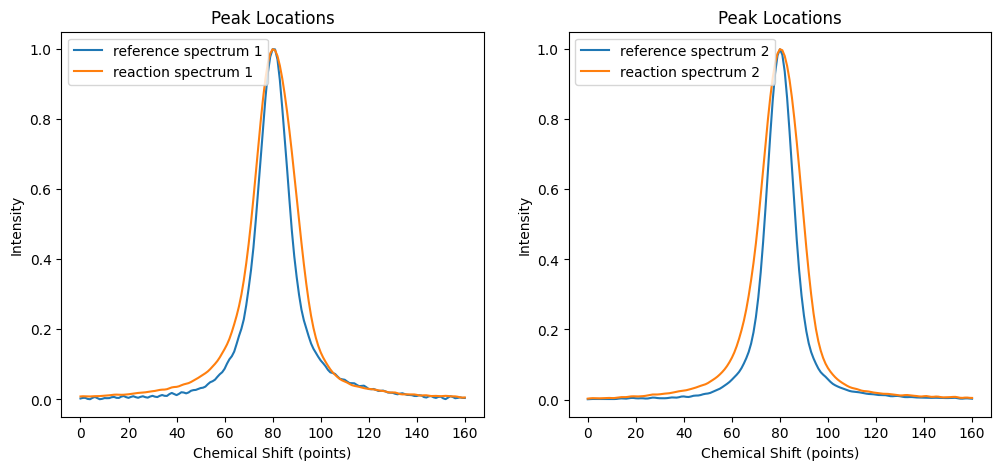

In [43]:
plot_margin_points = 80

reference_slice_peak1 = reference_spectrum1[peak1_reference_position_index-plot_margin_points:peak1_reference_position_index+plot_margin_points+1]
# reference_slice_peak1 /= np.max(reference_slice_peak1)
reaction_slice_peak1 = reaction_spectra[0][peak1_reaction_position_index-plot_margin_points:peak1_reaction_position_index+plot_margin_points+1]
# reaction_slice_peak1 /= np.max(reaction_slice_peak1)
reference_slice_peak2 = reference_spectrum2[peak2_reference_position_index-plot_margin_points:peak2_reference_position_index+plot_margin_points+1]
# reference_slice_peak2 /= np.max(reference_slice_peak2)
reaction_slice_peak2 = reaction_spectra[-1][peak2_reaction_position_index-plot_margin_points:peak2_reaction_position_index+plot_margin_points+1]
# reaction_slice_peak2 /= np.max(reaction_slice_peak2)

fig, axs = plt.subplots(ncols=2, figsize=(12, 5))
axs[0].plot(reference_slice_peak1, label="reference spectrum 1")
axs[0].plot(reaction_slice_peak1, label="reaction spectrum 1")
axs[0].set_xlabel("Chemical Shift (points)")
axs[0].set_ylabel("Intensity")
axs[0].set_title("Peak Locations")
axs[0].legend()
axs[1].plot(reference_slice_peak2, label="reference spectrum 2")
axs[1].plot(reaction_slice_peak2, label="reaction spectrum 2")
axs[1].set_xlabel("Chemical Shift (points)")
axs[1].set_ylabel("Intensity")
axs[1].set_title("Peak Locations")
axs[1].legend()
plt.show()

### test for the first reaction spectrum

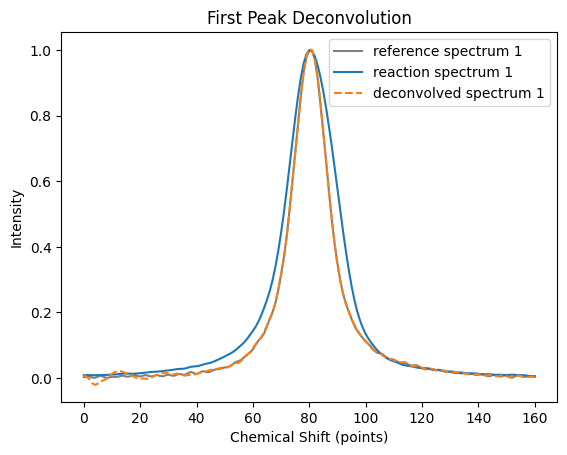

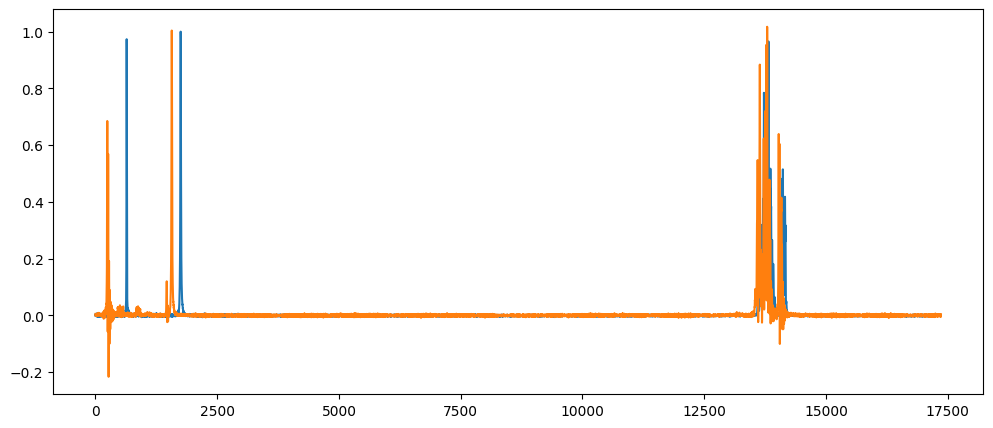

In [84]:
margin = 80
spectrum = reaction_spectra[0]
peak_position = get_peak_location(reaction_chemical_shifts, spectrum, peak1_reaction_position_ppm)
reaction_spectrum_first_deconvolved_peak1 = deconvolve_spectrum_fiddle(reference_slice_peak1, spectrum, peak_position, margin=margin)

plt.figure()
plt.plot(reference_spectrum1[peak1_reference_position_index-plot_margin_points:peak1_reference_position_index+plot_margin_points+1], label="reference spectrum 1", c='0.5')
plt.plot(spectrum[peak_position-plot_margin_points:peak_position+plot_margin_points+1], label="reaction spectrum 1")
plt.plot(reaction_spectrum_first_deconvolved_peak1[peak_position-plot_margin_points:peak_position+plot_margin_points+1], label="deconvolved spectrum 1", linestyle='dashed')
plt.xlabel("Chemical Shift (points)")
plt.ylabel("Intensity")
plt.title("First Peak Deconvolution")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(reference_spectrum1)
plt.plot(reaction_spectrum_first_deconvolved_peak1)

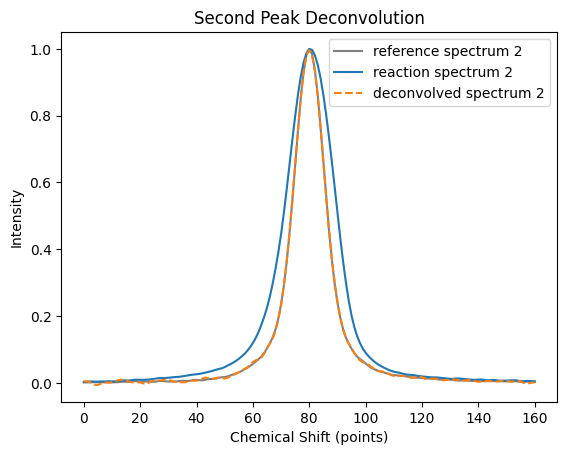

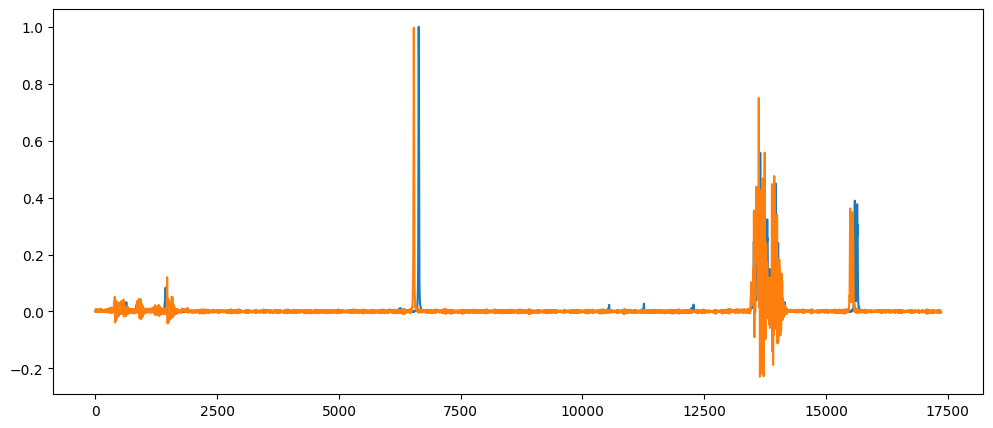

In [53]:
margin = 80
spectrum = reaction_spectra[-1]
peak_position = get_peak_location(reaction_chemical_shifts, spectrum, peak2_reaction_position_ppm)
reaction_spectrum_second_deconvolved_peak2 = deconvolve_spectrum_fiddle(reference_slice_peak2, spectrum, peak_position, margin=margin)

plt.figure()
plt.plot(reference_spectrum2[peak2_reference_position_index-plot_margin_points:peak2_reference_position_index+plot_margin_points+1], label="reference spectrum 2", c='0.5')
plt.plot(spectrum[peak_position-plot_margin_points:peak_position+plot_margin_points+1], label="reaction spectrum 2")
plt.plot(reaction_spectrum_second_deconvolved_peak2[peak_position-plot_margin_points:peak_position+plot_margin_points+1], label="deconvolved spectrum 2", linestyle='dashed')
plt.xlabel("Chemical Shift (points)")
plt.ylabel("Intensity")
plt.title("Second Peak Deconvolution")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(reference_spectrum2)
plt.plot(reaction_spectrum_second_deconvolved_peak2)

## Theoretical peaks

In [60]:
from scipy.signal import find_peaks, find_peaks_cwt, peak_widths, peak_prominences

In [ ]:
from scipy.optimize import curve_fit

# 1. Define the peak profile functions
def gaussian(x, amp, cen, wid):
    return amp * np.exp(-(x - cen)**2 / (2 * wid**2))

def lorentzian(x, amp, cen, wid):
    return (amp * wid**2) / ((x - cen)**2 + wid**2)

def mixture(x, amp_g, wid_g, amp_l, wid_l, cen):
    """Mixture with a shared center but separate amplitudes and widths"""
    return gaussian(x, amp_g, cen, wid_g) + lorentzian(x, amp_l, cen, wid_l)

def gaussian_initial_guess(x, y):
    cen = x[np.argmax(y)]
    amp = np.max(y)
    wid = peak_widths(y, [np.argmax(y)])[0][0] / 2.355  # FWHM to std dev
    return amp, cen, wid

def lorentzian_initial_guess(x, y):
    cen = x[np.argmax(y)]
    amp = np.max(y)
    wid = peak_widths(y, [np.argmax(y)])[0][0] / 2  # FWHM to HWHM
    return amp, cen, wid

def get_gaussian_fit(y):
    x = np.arange(len(y))

    initial_guess = gaussian_initial_guess(x, y)
    popt, _ = curve_fit(gaussian, xdata=x, ydata=y, p0=initial_guess)
    return gaussian(x, *popt)

def get_lorentzian_fit(y):
    x = np.arange(len(y))

    initial_guess = lorentzian_initial_guess(x, y)
    popt, _ = curve_fit(lorentzian, xdata=x, ydata=y, p0=initial_guess)
    return lorentzian(x, *popt)

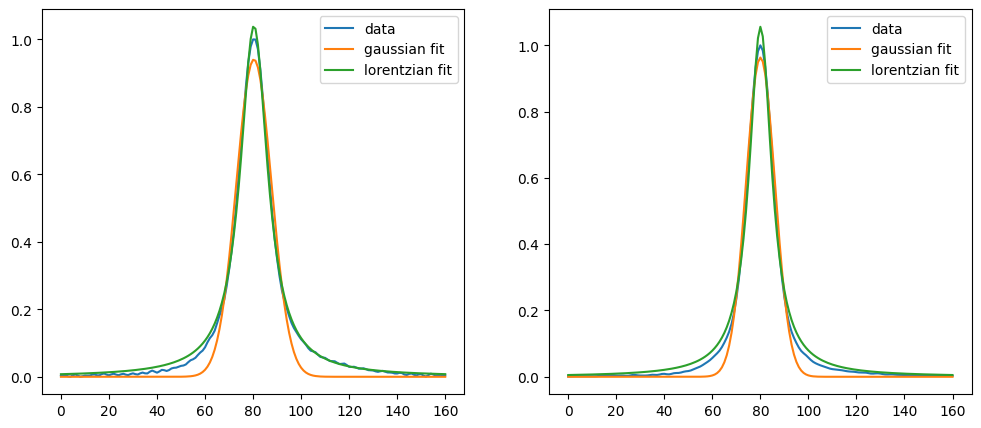

In [77]:
gaussian_fit_peak1 = get_gaussian_fit(reference_slice_peak1)
lorentzian_fit_peak1 = get_lorentzian_fit(reference_slice_peak1)
gaussian_fit_peak2 = get_gaussian_fit(reference_slice_peak2)
lorentzian_fit_peak2 = get_lorentzian_fit(reference_slice_peak2)

fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

axs[0].plot(reference_slice_peak1, label="data")
axs[0].plot(gaussian_fit_peak1, label="gaussian fit")
axs[0].plot(lorentzian_fit_peak1, label="lorentzian fit")
axs[0].legend()

axs[1].plot(reference_slice_peak2, label="data")
axs[1].plot(gaussian_fit_peak2, label="gaussian fit")
axs[1].plot(lorentzian_fit_peak2, label="lorentzian fit")
axs[1].legend()


### First reaction spectrum, Lorenzian peak

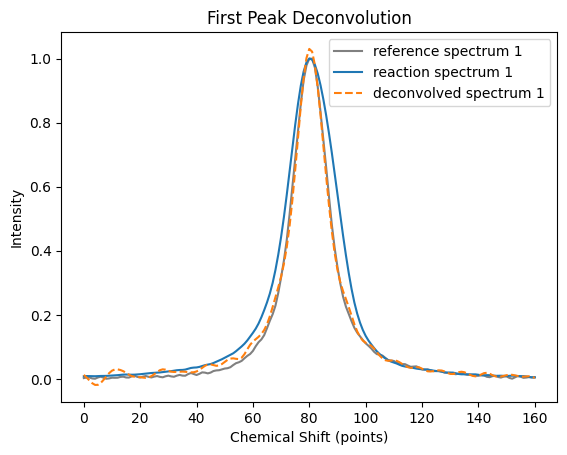

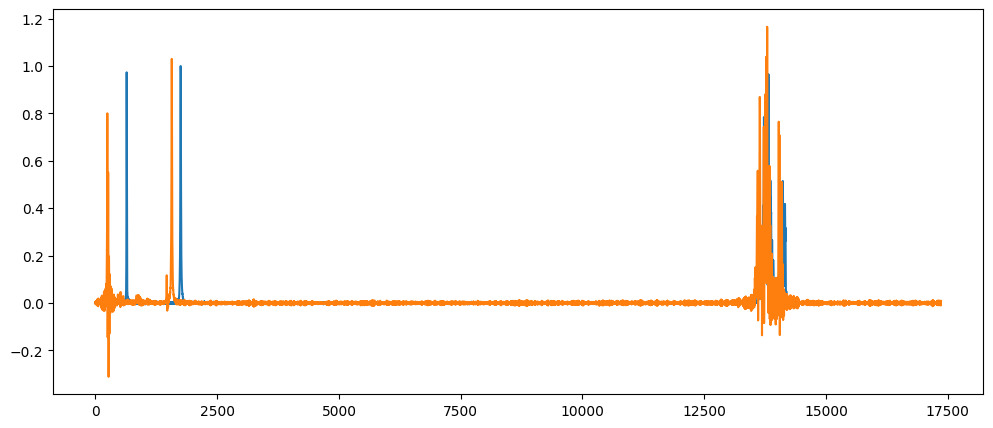

In [94]:
margin = 80
spectrum = reaction_spectra[0]
peak_position = get_peak_location(reaction_chemical_shifts, spectrum, peak1_reaction_position_ppm)
reaction_spectrum_first_deconvolved_peak1_lorenz = deconvolve_spectrum_fiddle(lorentzian_fit_peak1, spectrum, peak_position, margin=margin)

plt.figure()
plt.plot(reference_spectrum1[peak1_reference_position_index-plot_margin_points:peak1_reference_position_index+plot_margin_points+1], label="reference spectrum 1", c='0.5')
plt.plot(spectrum[peak_position-plot_margin_points:peak_position+plot_margin_points+1], label="reaction spectrum 1")
plt.plot(reaction_spectrum_first_deconvolved_peak1_lorenz[peak_position-plot_margin_points:peak_position+plot_margin_points+1], label="deconvolved spectrum 1", linestyle='dashed')
plt.xlabel("Chemical Shift (points)")
plt.ylabel("Intensity")
plt.title("First Peak Deconvolution")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(reference_spectrum1)
plt.plot(reaction_spectrum_first_deconvolved_peak1_lorenz)

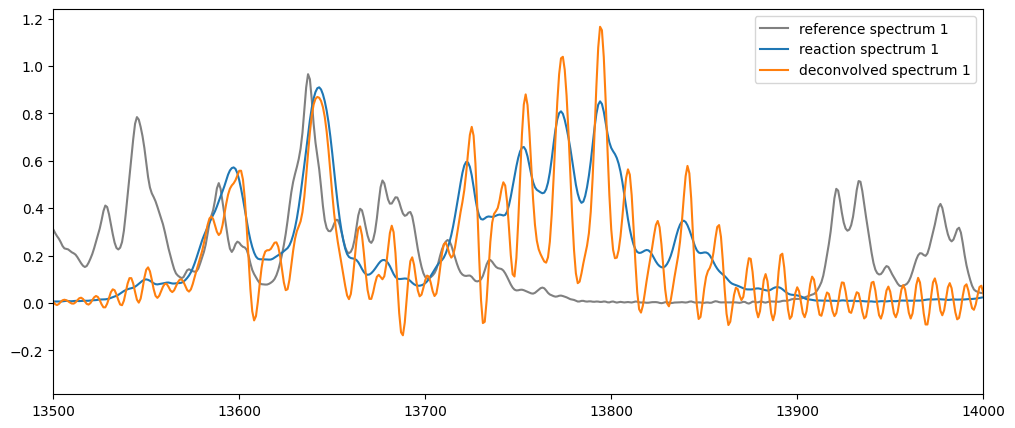

In [108]:
plt.figure(figsize=(12, 5))
plt.plot(reference_spectrum1[183:], color='0.5', label="reference spectrum 1")
plt.plot(reaction_spectra[0], label="reaction spectrum 1")
plt.plot(reaction_spectrum_first_deconvolved_peak1_lorenz, label="deconvolved spectrum 1")
plt.xlim(13_500, 14000)
# plt.xlim(1566-100, 1566+50)
plt.legend()

### Last reaction spectrum, Lorenzian peak

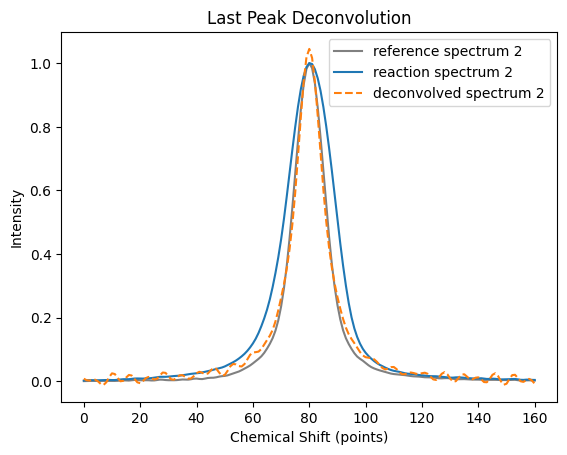

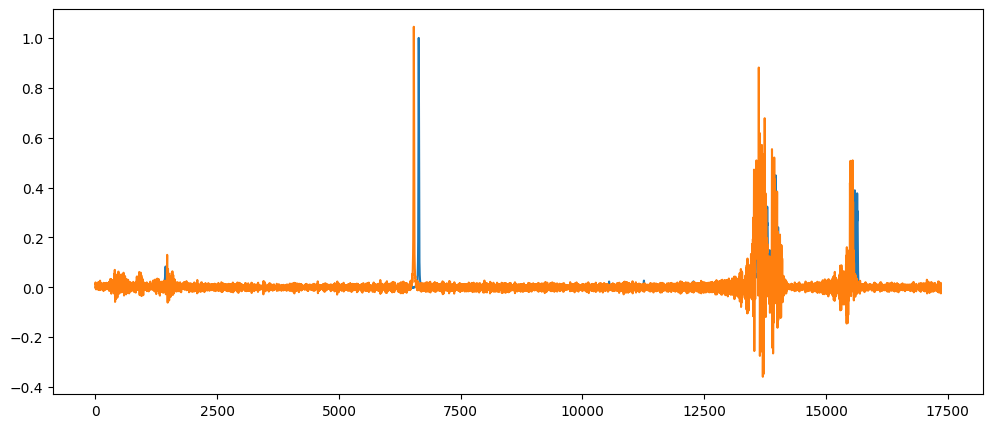

In [109]:
margin = 80
spectrum = reaction_spectra[-1]
peak_position = get_peak_location(reaction_chemical_shifts, spectrum, peak2_reaction_position_ppm)
reaction_spectrum_last_deconvolved_peak2_lorenz = deconvolve_spectrum_fiddle(lorentzian_fit_peak2, spectrum, peak_position, margin=margin)

plt.figure()
plt.plot(reference_spectrum2[peak2_reference_position_index-plot_margin_points:peak2_reference_position_index+plot_margin_points+1], label="reference spectrum 2", c='0.5')
plt.plot(spectrum[peak_position-plot_margin_points:peak_position+plot_margin_points+1], label="reaction spectrum 2")
plt.plot(reaction_spectrum_last_deconvolved_peak2_lorenz[peak_position-plot_margin_points:peak_position+plot_margin_points+1], label="deconvolved spectrum 2", linestyle='dashed')
plt.xlabel("Chemical Shift (points)")
plt.ylabel("Intensity")
plt.title("Last Peak Deconvolution")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(reference_spectrum2)
plt.plot(reaction_spectrum_last_deconvolved_peak2_lorenz)

In [113]:
peak_position

np.int64(6537)

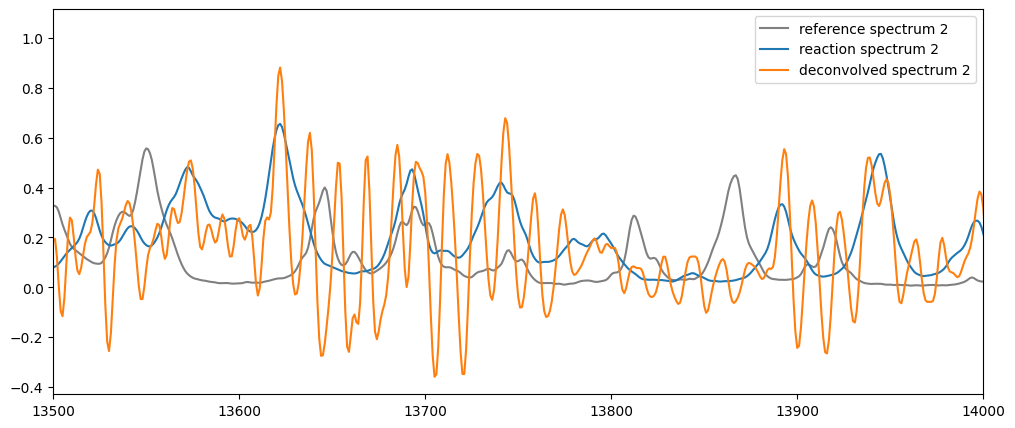

In [121]:
plt.figure(figsize=(12, 5))
plt.plot(reference_spectrum2[101:], color='0.5', label="reference spectrum 2")
plt.plot(reaction_spectra[-1], label="reaction spectrum 2")
plt.plot(reaction_spectrum_last_deconvolved_peak2_lorenz, label="deconvolved spectrum 2")
plt.xlim(13_500, 14000)
# plt.xlim(6537-50, 6537+50)
plt.legend()